In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import json
import os

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
IMG_DIR = os.path.join(BASE_DIR, 'data/images')
TRAIN_JSON = os.path.join(BASE_DIR, 'data/labels', 'train_map.json')

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Praca na: {DEVICE}")

train_transforms = transforms.Compose([
    transforms.Resize((624, 624)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

class BalancedUrbanDataset(Dataset):
    def __init__(self, json_file, img_dir, samples_per_class=100, transform=None):
        with open(json_file, 'r') as f:
            full_map = json.load(f)
        
        self.img_dir = img_dir
        self.transform = transform
        
        cat_to_paths = {}
        for path, cat in full_map.items():
            if cat not in cat_to_paths: cat_to_paths[cat] = []
            cat_to_paths[cat].append(path)
        
        self.categories = sorted(list(cat_to_paths.keys()))
        self.class_to_idx = {cat: i for i, cat in enumerate(self.categories)}
        
        self.final_samples = []
        for cat in self.categories:
            paths = cat_to_paths[cat]
            for i in range(samples_per_class):
                path = paths[i % len(paths)]
                self.final_samples.append((path, self.class_to_idx[cat]))
                
        print(f"Załadowano {len(self.categories)} klas. Łącznie {len(self.final_samples)} obrazów (po 100 na klasę).")

    def __len__(self):
        return len(self.final_samples)

    def __getitem__(self, idx):
        path, label = self.final_samples[idx]
        img = Image.open(os.path.join(self.img_dir, path)).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

def get_model(num_classes):
    model = models.resnet18(weights='IMAGENET1K_V1')
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)
    return model.to(DEVICE)

dataset = BalancedUrbanDataset(TRAIN_JSON, IMG_DIR, samples_per_class=100, transform=train_transforms)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

model = get_model(len(dataset.categories))
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("\nRozpoczynam trening...")
model.train()

for epoch in range(10):
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    acc = 100 * correct / total
    print(f"Epoka [{epoch+1}/10] | Loss: {running_loss/len(loader):.4f} | Accuracy: {acc:.2f}%")

torch.save(model.state_dict(), "urban_model_v2.pth")
print("\nModel zapisany w folderze /models")

Praca na: cuda
Załadowano 6 klas. Łącznie 600 obrazów (po 100 na klasę).

Rozpoczynam trening...
Epoka [1/10] | Loss: 1.1179 | Accuracy: 62.50%
Epoka [2/10] | Loss: 0.8942 | Accuracy: 68.00%
Epoka [3/10] | Loss: 0.7905 | Accuracy: 72.33%
Epoka [4/10] | Loss: 0.6446 | Accuracy: 78.50%
Epoka [5/10] | Loss: 0.6062 | Accuracy: 81.00%
Epoka [6/10] | Loss: 0.5062 | Accuracy: 83.33%
Epoka [7/10] | Loss: 0.5208 | Accuracy: 83.17%
Epoka [8/10] | Loss: 0.3589 | Accuracy: 88.83%
Epoka [9/10] | Loss: 0.4294 | Accuracy: 85.00%
Epoka [10/10] | Loss: 0.3725 | Accuracy: 85.83%

Model zapisany w folderze /models


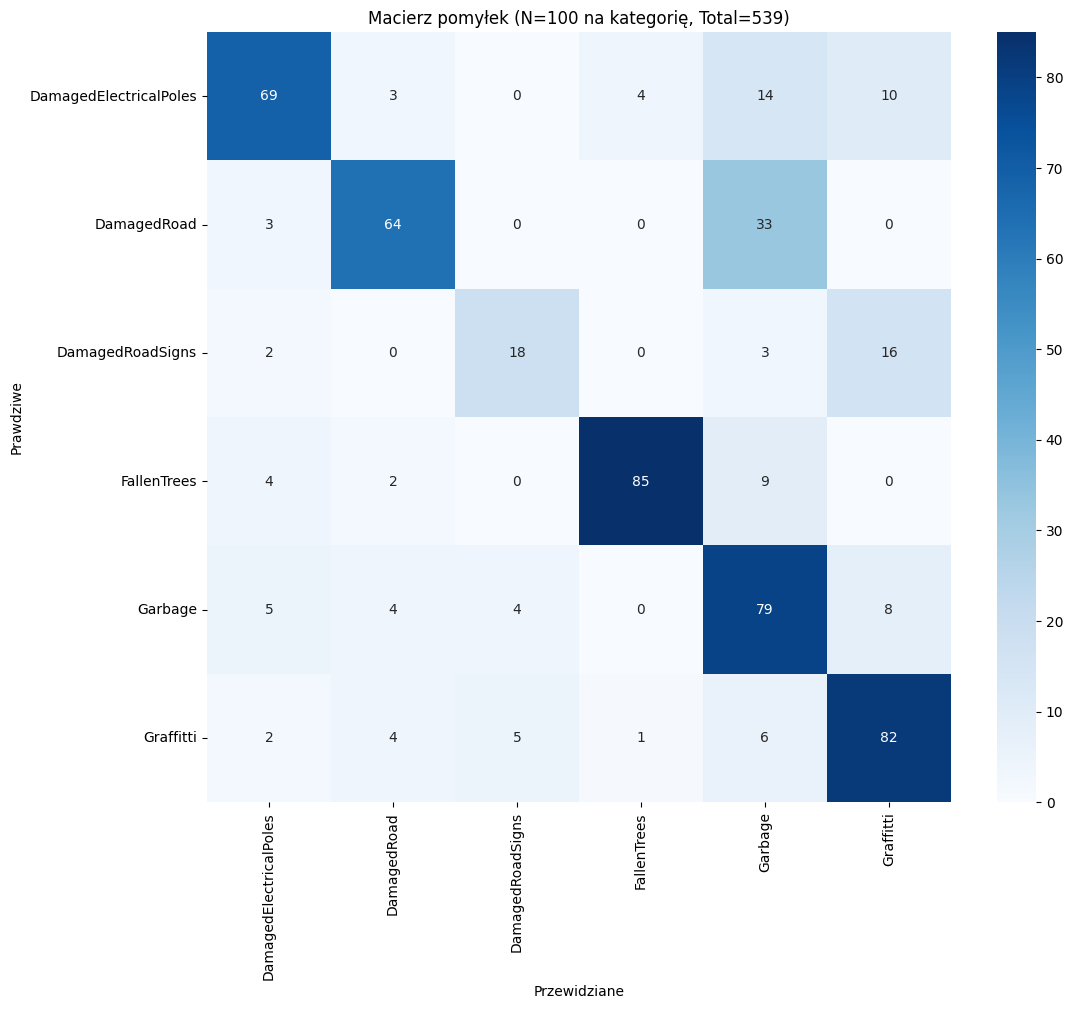


Skuteczność na próbie: 73.65% (397/539)


In [8]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cat_to_paths = {}
for path, cat in dataset_test.full_map.items():
    if cat not in cat_to_paths: cat_to_paths[cat] = []
    cat_to_paths[cat].append(path)

limited_samples = []
for cat in dataset_test.categories:
    paths = cat_to_paths[cat]
    selected_paths = paths[:100]
    for p in selected_paths:
        limited_samples.append((p, dataset_test.class_to_idx[cat]))

dataset_test.samples = limited_samples
test_loader = DataLoader(dataset_test, batch_size=16, shuffle=False)

y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=dataset_test.categories, 
            yticklabels=dataset_test.categories)
plt.xlabel('Przewidziane')
plt.ylabel('Prawdziwe')
plt.title(f'Macierz pomyłek (N=100 na kategorię, Total={len(y_true)})')
plt.show()

correct = np.sum(np.array(y_true) == np.array(y_pred))
print(f"\nSkuteczność na próbie: {100 * correct / len(y_true):.2f}% ({correct}/{len(y_true)})")